#1. Import Dataset

In [ ]:
import tensorflow as tf


In [ ]:
from google.colab import drive
import numpy as np
import pandas as pd


drive.mount('/content/drive/', force_remount=True)

dir = '/content/drive/My Drive/TA/'
import sys
sys.path.insert(0, dir)


import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings
from CombinedDecays import CombinedDecays
import datetime


Mounted at /content/drive/


In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      print(f"Found GPU: {gpu.name}")
  except RuntimeError as e:
    print(e)
else:
  print("No GPU devices found.")

No GPU devices found.


In [ ]:
df = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/CO_Land_Grid_Jabodetabek.csv")
wind = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/Wind_CO_MeanDaily_Jabodetabek.csv")


#2. Class Definition

In [ ]:
import tensorflow as tf
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings

DTYPE='float32'

class MultiSigmaFourierFeatures(tf.keras.layers.Layer):
    def __init__(self, sigmas, mapping_size, trainable_B=False, **kwargs):
        super().__init__(**kwargs)
        self.sigmas = sigmas
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.fourier_layers = [
            FourierFeatureMapping(
                mapping_size=self.mapping_size,
                sigma=sigma,
                trainable_B=self.trainable_B
            ) for sigma in self.sigmas
        ]

    def call(self, inputs):
        outputs = [layer(inputs) for layer in self.fourier_layers]
        return tf.concat(outputs, axis=-1)



class FourierFeatureMapping(tf.keras.layers.Layer):
    def __init__(self, mapping_size=256, sigma=1.0, trainable_B=False, **kwargs):
        super(FourierFeatureMapping, self).__init__(**kwargs)
        self.mapping_size = mapping_size
        self.sigma = sigma
        self.trainable_B = trainable_B

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # Use RandomNormal initializer with stddev = sigma
        self.B = self.add_weight(
            name="B_matrix",
            shape=(input_dim, self.mapping_size),
            initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=self.sigma),
            trainable=self.trainable_B
        )

    def call(self, inputs):
        proj = tf.matmul(inputs, self.B)
        return tf.concat([tf.sin(proj), tf.cos(proj)], axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "mapping_size": self.mapping_size,
            "sigma": self.sigma,
            "trainable_B": self.trainable_B
        })
        return config

# Define model architecture for 2D spatial domain with time
class PINN_NeuralNet(tf.keras.Model):
    def __init__(self, lb, ub,
                 output_dim=1,
                 num_hidden_layers=8,
                 num_neurons_per_layer=20,
                 activation='tanh',
                 mapping_size=256,
                 sigma=1.0,
                 sigmas=[1.0, 3.0],
                 kernel_initializer='glorot_normal',
                 trainable_B=True,
                 **kwargs):
        super().__init__(**kwargs)
        self.lb = lb
        self.ub = ub
        self.num_hidden_layers = num_hidden_layers
        self.output_dim = output_dim
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.sigmas = sigmas
        self.scale = tf.keras.layers.Lambda(lambda x: 2.0*(x - lb)/(ub - lb) - 1.0)
        self.fourier_features = MultiSigmaFourierFeatures(sigmas=self.sigmas, mapping_size=self.mapping_size, trainable_B=True)
        # self.fourier_features = FourierFeatureMapping(mapping_size=mapping_size, sigma=sigma, trainable_B=trainable_B)

        # dummy_input = tf.keras.Input(shape=(3,))
        # _ = self.fourier_features(dummy_input)

        self.hidden = [tf.keras.layers.Dense(num_neurons_per_layer,
                                             activation=tf.keras.activations.get(activation),
                                             kernel_initializer=kernel_initializer)
                       for _ in range(self.num_hidden_layers)]
        self.out = tf.keras.layers.Dense(output_dim)


    def call(self, X):
        """Forward-pass through neural network."""
        X = tf.convert_to_tensor(X, dtype=tf.float32)  # Ensure X is a Tensor
        X = tf.reshape(X, (-1, 3))  # Ensure input is 2D (batch_size, features) for [t, x, y]
        Z = self.scale(X)
        Z = self.fourier_features(Z)
        for i in range(self.num_hidden_layers):
            Z = self.hidden[i](Z)
        return self.out(Z)


class PINN_PDESolver():
    def __init__(self, model, X_r, fun_r, get_r,lambd=1):
        self.model = model

        # Store collocation points
        # X_r = tf.convert_to_tensor(X_r, dtype=tf.float32)  # Ensure X_r is a Tensor
        self.t = X_r[:,0:1]
        self.x = X_r[:,1:2]
        self.y = X_r[:,2:3]
        self.lambd = lambd
        # Initialize history of losses and global iteration counter
        self.hist = []
        self.lambd_list = []  # Initialize lambda list here
        self.iter = 0
        self.fun_r = fun_r
        self.get_r_fn = get_r

    def get_r(self, t, x, y, u_data, Wu=None, Wv=None): # Added default None for Wu, Wv
        return self.get_r_fn(t=t, x=x, y=y, model=self.model, lambd = self.lambd, fun_r=self.fun_r, u_data=u_data, Wu=Wu, Wv=Wv)


    def loss_fn(self, X, u, Wu, Wv):
        # X = tf.convert_to_tensor(X, dtype=tf.float32)
        # X = tf.reshape(X, (-1, 3))  # Ensure input is 3D [t, x, y]
        # u = tf.convert_to_tensor(u, dtype=tf.float32)

        # Compute phi_r
        t = X[:, 0:1]
        x = X[:, 1:2]
        y = X[:, 2:3]
        r = self.get_r(t, x, y, u, Wu, Wv)
        phi_r = r

        # Initialize loss
        loss = phi_r

        return loss, phi_r
    @tf.function
    def get_grad(self, X, u, Wu, Wv):
        X = tf.cast(X, tf.float32)
        u = tf.cast(u, tf.float32)
        Wu = tf.cast(Wu, tf.float32)
        Wv = tf.cast(Wv, tf.float32)


        with tf.GradientTape() as tape:
            loss, phi_r = self.loss_fn(X, u, Wu, Wv)
        grad_theta = tape.gradient(loss, self.model.trainable_variables)

        return loss, grad_theta

    def solve_with_TFoptimizer(self, optimizer, X, u, W_u, W_v, inverse=True, N=None, min_loss=None, timeout=None, batch_size=None):
        """
        Modified training loop that keeps the loss_callback function and reports loss per iteration.
        """
        X = tf.convert_to_tensor(X, dtype=tf.float32)
        u = tf.convert_to_tensor(u, dtype=tf.float32)
        W_u = tf.convert_to_tensor(W_u, dtype=tf.float32)
        W_v = tf.convert_to_tensor(W_v, dtype=tf.float32)


        data = tf.data.Dataset.from_tensor_slices((X, u, W_u, W_v))

        if batch_size is not None:
            data = data.shuffle(buffer_size=len(X)).batch(batch_size).map(
                lambda x, u_batch, wu, wv: (tf.cast(x, tf.float32), tf.cast(u_batch, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))
            ).prefetch(tf.data.AUTOTUNE)
        else:
            data = data.batch(len(X)).map(
                lambda x, u_batch, wu, wv: (tf.cast(x, tf.float32), tf.cast(u_batch, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))
            ).prefetch(tf.data.AUTOTUNE)


        # The loss_callback now accepts the results of a step as arguments.
        def loss_callback(loss, phi_r, epoch_num):
            self.current_loss = loss.numpy()
            self.phi_r = phi_r.numpy()

            # Print every 50 iterations to avoid excessive output
            if self.iter % 50 == 0:
                print(f"Epoch {epoch_num}, Iteration {self.iter}, Loss: {self.current_loss:.6e}, Phi_r: {self.phi_r:.6e}")

            self.hist.append(self.current_loss)
            self.iter += 1

        start_time = time.time()
        epochs = N if N is not None else 1000 # Set a default number of epochs if N isn't specified

        # Explicit loops for epochs and iterations (batches)
        for epoch in range(epochs):
            if timeout is not None and (time.time() - start_time > timeout):
                print("Timeout reached. Stopping training.")
                break

            total_epoch_loss = 0
            num_batches = 0
            for batch_X, batch_u, batch_Wu, batch_Wv in data:
                # Execute one training step (one batch)
                loss, grads = self.get_grad(batch_X, batch_u, batch_Wu, batch_Wv)
                optimizer.apply_gradients(zip(grads, self.model.trainable_variables))

                # Accumulate loss for the epoch
                total_epoch_loss += loss.numpy()
                num_batches += 1

                # Recalculate phi_r for reporting (optional, can be removed for speed)
                # phi_r = self.loss_fn(batch_X, batch_u, batch_Wu, batch_Wv)[1]
                # loss_callback(loss, phi_r, epoch + 1) # Callback per batch (noisy)

            # Calculate average epoch loss and call callback once per epoch
            avg_epoch_loss = total_epoch_loss / num_batches if num_batches > 0 else 0
            # We don't have phi_r readily available as it's calculated per batch,
            # so we'll just report the average epoch loss.
            self.current_loss = avg_epoch_loss
            self.hist.append(self.current_loss)
            self.iter += 1 # Increment iteration counter once per epoch

            # Print every epoch
            print(f"--- End of Epoch {epoch+1}, Iteration {self.iter}, Average Epoch Loss: {self.current_loss:.6e} ---")


            if min_loss is not None and self.current_loss < min_loss:
                print(f"Minimum loss of {min_loss} reached. Stopping training.")
                break


    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print('It {:05d}: l_u = {:10.8e} loss = {:10.8e}'.format(self.iter,self.phi_0_b,self.current_loss))
        self.hist.append(self.current_loss)
        self.iter+=1

    def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
        upred = self.model(tf.cast(test_data, DTYPE))  # shape: [N, 1]

        # Reshape into [Nt+1, Nx+1, Ny+1]
        Nt, Nx, Ny = len(t_unique) - 1, len(x_unique) - 1, len(y_unique) - 1
        U = upred.numpy().reshape(Nt+1, Nx+1, Ny+1)

        # Create meshgrid for visualization
        T, X, Y = np.meshgrid(t_unique, x_unique, y_unique, indexing='ij')
        self.T_pred, self.X_pred, self.Y_pred = T, X, Y

        return U

    def plot_solution_at_time(self, U=None, time_idx=0, **kwargs):
        # If upred has not been predicted
        if U is None:
            U = self.predict_solution()

        # Plot solution at specific time
        fig = plt.figure(figsize=(9,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(self.X_pred[time_idx], self.Y_pred[time_idx], U[time_idx], cmap='viridis', **kwargs)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$y$')
        ax.set_zlabel('$u_\\theta(t,x,y)$')
        ax.set_title(f'Solution at t = {self.T_pred[time_idx,0,0]:.2f}')
        return ax

    def plot_loss_history(self, ax=None):
        if not ax:
            fig = plt.figure(figsize=(7,5))
            ax = fig.add_subplot(111)
        ax.semilogy(range(len(self.hist)), self.hist,'k-')
        ax.set_xlabel('$n_{epoch}$')
        ax.set_ylabel('$\\phi^{n_{epoch}}$')
        return ax



def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
    upred = self(tf.cast(test_data, DTYPE))  # shape: [N, 1]

    #     # Reshape into [Nt+1, Nx+1, Ny+1]
    # Nt, Nx, Ny = len(t_unique) - 1, len(x_unique) - 1, len(y_unique) - 1
    # U = upred.numpy().reshape(Nt+1, Nx+1, Ny+1)

    #     # Create meshgrid for visualization
    # T, X, Y = np.meshgrid(t_unique, x_unique, y_unique, indexing='ij')
    # self.T_pred, self.X_pred, self.Y_pred = T, X, Y

    return upred

def calculate_mae(u_pred, u_true):
    """Calculate Mean Absolute Error"""
    return np.mean(np.abs(u_true - u_pred))

def calculate_mape(u_pred, u_true, epsilon=1e-10):
    """Calculate Mean Absolute Percentage Error"""
    return 100 * np.mean(np.abs((u_true - u_pred) / (np.abs(u_true) + epsilon)))

def evaluate_solution(u_pred, u_true):
    """Evaluate solution using MAE and MAPE"""
    mae = calculate_mae(u_pred, u_true)
    mape = calculate_mape(u_pred, u_true)
    # r2 =   calculate_rel_l2(u_pred, u_true)

    return mae, mape

def calculate_rel_l2(u_pred, u_true, epsilon=1e-10):
    """Relative L2 norm error"""
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + epsilon)


def evaluate_param(lambda_pred, lambda_true):
    """Evaluate parameter using absolute error and percentage error"""
    abs_error = np.abs(lambda_true - lambda_pred)
    perc_error = 100 * abs_error / np.abs(lambda_true)
    return abs_error, perc_error

def plot_solution_slice(U, T, X, Y, time_idx=0):
    """Plot solution slice at specific time index"""
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X[time_idx], Y[time_idx], U[time_idx],
                          cmap='viridis', edgecolor='none')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u(t,x,y)')
    ax.set_title(f'Solution at t = {T[time_idx,0,0]:.2f}')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()


class Hybrid_IdentificationNet(PINN_NeuralNet):
    def __init__(self, initial_lambda, beta=1e-4, *args, **kwargs):
        # Call init of base class
        super().__init__(*args,**kwargs)
        self.initial_lambda = initial_lambda

        if isinstance(initial_lambda, (list, np.ndarray)):
            self.initial_lambda = np.array(initial_lambda, dtype=DTYPE)
        else:
            self.initial_lambda = initial_lambda

        # Initialize variable for lambda
        self.lambd = tf.Variable(initial_value=self.initial_lambda, trainable=True, dtype=DTYPE, constraint=lambda x: tf.clip_by_value(x, 1e-5, 10.0))
        self.lambd_list = []
        # self.beta = beta

        # # -- Parameters for the Gaussian Source Term --
        # # Strength of the source (needs to be positive)
        # self.source_A = tf.Variable(1.0, trainable=True, dtype=DTYPE,
        #                             constraint=lambda x: tf.nn.softplus(x)) # Ensures A > 0

        # # Center of the source
        # self.source_x0 = tf.Variable(0.0, trainable=True, dtype=DTYPE)
        # self.source_y0 = tf.Variable(0.0, trainable=True, dtype=DTYPE)

        # # Spread of the source (needs to be positive)
        # self.source_sigma_x = tf.Variable(1.0, trainable=True, dtype=DTYPE,
        #                                   constraint=lambda x: tf.nn.softplus(x)) # Ensures sigma > 0
        # # self.source_sigma_y = tf.Variable(1.0, trainable=True, dtype=DTYPE,
        # #                                   constraint=lambda x: tf.nn.softplus(x)) # Ensures sigma > 0

    def build(self, input_shape):
           super().build(input_shape)  # Ensure layers are initialized
           self.built = True


    def add_param(self):
        try:
          len(self.initial_lambda)
          self.initial_lambda = np.array(self.initial_lambda, dtype=DTYPE)
        except TypeError as e:
          pass

    @property
    def trainable_variables(self):
        # Combine neural network weights with lambda parameter
        return super().trainable_variables + [self.lambd]

class Hybrid_IdentificationSolver(PINN_PDESolver):
    def solve_with_TFoptimizer(self, optim_fwd, optim_param, get_r_param, X, u, W_u, W_v,
                               N_fwd=None, min_loss_fwd=None, timeout_fwd=None,
                               N_param=None, min_loss_param=None, timeout_param=None, modified=False, batch_size=None, **kwargs):
        self.changed = False
        self.lambd_list = []

        # Forward pass optimization
        super().solve_with_TFoptimizer(optim_fwd, X, u, W_u, W_v, N=N_fwd, min_loss=min_loss_fwd, timeout=timeout_fwd, batch_size=batch_size)

        # Add parameters after fitting with given data.
        self.model.add_param()
        self.changed = True

        print('\n\nFinding PDE parameters.')

        # Parameter optimization
        data = tf.data.Dataset.from_tensor_slices((X, u, W_u, W_v))
        if batch_size is not None:
            data = data.shuffle(buffer_size=len(X)).batch(batch_size).map(lambda x, u, wu, wv: (tf.cast(x, tf.float32), tf.cast(u, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))).prefetch(tf.data.AUTOTUNE)
        else:
            data = data.batch(len(X)).map(lambda x, u, wu, wv: (tf.cast(x, tf.float32), tf.cast(u, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))).prefetch(tf.data.AUTOTUNE) # Process all data as a single batch

        @tf.function
        def train_step_param():
            total_loss = 0.0
            num_batches = 0
            for batch_X, batch_u, batch_Wu, batch_Wv in data:
                batch_t = batch_X[:, 0:1]
                batch_x = batch_X[:, 1:2]
                batch_y = batch_X[:, 2:3]
                loss, grad_theta = get_r_param(batch_t, batch_x, batch_y, batch_Wu, batch_Wv, self.model)
                optim_param.apply_gradients(zip([grad_theta], [self.model.lambd]))
                total_loss += loss
                num_batches += 1
            return total_loss / tf.cast(num_batches, tf.float32)

        def loss_callback():
            loss = train_step_param()
            self.current_loss = loss.numpy()
            callback()

        def callback():
                lambd = self.model.lambd.numpy()
                self.model.lambd_list.append(lambd)

                if self.iter % 1 == 0:
                    print('It {:05d}: loss = {:10.8e} lambda = '.format(self.iter, self.current_loss) + str(lambd))

                self.hist.append(self.current_loss)
                self.iter += 1

        start_time = time.time()
        if N_param is not None:
            for _ in range(N_param):
                loss_callback()
            print ('{} iterations reached.'.format(N_param))
        elif min_loss_param is not None:
            while True:
                loss_callback()
                if self.current_loss < min_loss_param:
                    print ('Loss is reached. Current loss: {:10.8e}'.format(self.current_loss))
                    break
        elif timeout_param is not None:
            stop_after = time.time() + timeout_param
            while True:
                loss_callback()
                if time.time() > stop_after:
                    print ('Timeout is reached. Time elapsed: {} seconds'.format(time.time()-start_time))
                    break

    def loss_fn(self, X, u, Wu, Wv):
        # Initialize loss
        loss = 0
        phi_r = 0

        # phi_r is calculated only after
        # variables are added.
        if self.changed is not False:
            # Compute phi_r
            t = X[:, 0:1]
            x = X[:, 1:2]
            y = X[:, 2:3]
            # This part needs to be adjusted to get the corresponding W_u and W_v for the batch
            # For now, leaving it as is will likely cause an error here too if W_u and W_v are not batched.
            # A more robust solution would involve passing the wind data to loss_fn as well.
            r = self.get_r(t, x, y, u, Wu=Wu, Wv=Wv) # Pass Wu and Wv here
            phi_r =r
            # regularization_loss = self.beta / self.model.lambd
            loss += phi_r

        else:
            u_pred = self.model(X)
            loss += tf.reduce_mean(tf.square(u - u_pred))

        return loss, phi_r

    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print('It {:05d}: l_u = {:10.8e} loss = {:10.8e}'.format(self.iter,self.phi_0_b,self.current_loss))
            # print('It {:05d}: loss = {:10.8e}'.format(self.iter,self.current_loss))
        self.hist.append(self.current_loss)
        self.iter+=1

# Pra-pemrosesan Data

In [ ]:
df.columns

Index(['date', 'mean', 'longitude', 'latitude'], dtype='object')

In [ ]:
wind.dropna(inplace=True)
df.dropna(inplace = True)

In [ ]:
wind

,date,longitude,latitude,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed_10m,wind_direction_10m
1,2023-05-01,106.352747,-6.103510,0.104355,-0.164398,0.194722,122.406268
3,2023-05-01,106.348674,-6.077721,0.104355,-0.164398,0.194722,122.406268
4,2023-05-01,106.347774,-6.067024,0.104355,-0.164398,0.194722,122.406268
5,2023-05-01,106.352803,-6.054635,0.104355,-0.164398,0.194722,122.406268
7,2023-05-01,106.369068,-6.215194,0.050604,0.117666,0.128086,246.729149
...,...,...,...,...,...,...,...
2223574,2025-04-29,107.288205,-6.212286,-1.248562,-0.054484,1.249751,2.498655
2223575,2025-04-29,107.287719,-6.202429,-1.248562,-0.054484,1.249751,2.498655
2223576,2025-04-29,107.287021,-6.190315,-1.248562,-0.054484,1.249751,2.498655
2223577,2025-04-29,107.284628,-6.178768,-1.248562,-0.054484,1.249751,2.498655


In [ ]:
df

,date,mean,longitude,latitude
7,2023-05-01,0.029928,106.369068,-6.215194
8,2023-05-01,0.027871,106.367800,-6.124296
9,2023-05-01,0.027871,106.364432,-6.114336
10,2023-05-01,0.029764,106.362972,-6.103093
11,2023-05-01,0.029764,106.362972,-6.090743
...,...,...,...,...
2223574,2025-04-29,0.030331,107.288205,-6.212286
2223575,2025-04-29,0.030331,107.287719,-6.202429
2223576,2025-04-29,0.029587,107.287021,-6.190315
2223577,2025-04-29,0.029587,107.284628,-6.178768


In [ ]:
df['date'] = pd.to_datetime(df['date'])
start_date = datetime.datetime(2023, 5, 1)
df = df[(df['date'] >= start_date)]
df=df.rename(columns={"longitude":"x_coord","latitude":"y_coord"})
wind=wind.rename(columns={"longitude":"x_coord","latitude":"y_coord"})

df.sort_values(by=['date','x_coord','y_coord'], inplace=True)

In [ ]:
df.describe()

,date,mean,x_coord,y_coord
count,1355558,1.355558e+06,1.355558e+06,1.355558e+06
mean,2024-03-25 21:16:03.823901184,3.487244e-02,1.068063e+02,-6.388642e+00
min,2023-05-01 00:00:00,1.393031e-02,1.063478e+02,-6.782034e+00
25%,2023-09-19 00:00:00,2.972221e-02,1.065988e+02,-6.560043e+00
50%,2024-03-30 00:00:00,3.382610e-02,1.068033e+02,-6.387143e+00
75%,2024-09-04 00:00:00,3.896545e-02,1.070077e+02,-6.214243e+00
max,2025-04-29 00:00:00,7.176243e-02,1.072882e+02,-5.920041e+00
std,NaN,7.150899e-03,2.396757e-01,2.023308e-01


In [ ]:
wind.describe()

,x_coord,y_coord,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed_10m,wind_direction_10m
count,2.088530e+06,2.088530e+06,2.088530e+06,2.088530e+06,2.088530e+06,2.088530e+06
mean,1.068003e+02,-6.388153e+00,1.550690e-01,-2.488633e-02,8.679474e-01,1.696890e+02
std,2.416749e-01,1.987749e-01,1.031874e+00,5.001227e-01,7.660044e-01,1.093578e+02
min,1.063478e+02,-6.782034e+00,-5.212917e+00,-3.824649e+00,1.509067e-03,7.843643e-05
25%,1.065988e+02,-6.560043e+00,-3.687490e-01,-3.053499e-01,3.164065e-01,6.577277e+01
50%,1.067875e+02,-6.374793e+00,-3.203328e-02,-2.160454e-02,6.131772e-01,1.744352e+02
75%,1.070077e+02,-6.214243e+00,5.123361e-01,2.363907e-01,1.183421e+00,2.511733e+02
max,1.072882e+02,-5.941738e+00,6.126617e+00,2.163122e+00,6.444995e+00,3.599992e+02


## Pembersihan Data Polusi

In [ ]:
df=df.rename(columns={"mean":"CO_mean"})

df = df[df["CO_mean"]>=0]

wind['date'] = pd.to_datetime(wind['date'])

merged_df = pd.merge(df, wind, on=['x_coord', 'y_coord', 'date'], how='inner')

display(merged_df.head())

,date,CO_mean,x_coord,y_coord,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed_10m,wind_direction_10m
0,2023-05-01,0.029764,106.362972,-6.066043,0.071912,-0.107351,0.129251,124.295878
1,2023-05-01,0.029764,106.362972,-6.078393,0.071912,-0.107351,0.129251,124.295878
2,2023-05-01,0.029764,106.362972,-6.053693,0.071912,-0.107351,0.129251,124.295878
3,2023-05-01,0.029764,106.362972,-6.090743,0.071912,-0.107351,0.129251,124.295878
4,2023-05-01,0.029764,106.362972,-6.103093,0.067856,-0.100220,0.121067,124.532079


## Rata-rata Kecepatan Angin

In [ ]:
merged_df= merged_df.rename(columns = {"u_component_of_wind_10m":'u10',"v_component_of_wind_10m":'v10'})
merged_df = merged_df[["date","CO_mean","u10","v10","x_coord","y_coord"]]

merged_df['u10']  = merged_df.groupby(['x_coord','y_coord'])['u10'].transform('mean')
merged_df['v10']  = merged_df.groupby(['x_coord','y_coord'])['v10'].transform('mean')

In [ ]:
merged_df.describe()

,date,CO_mean,u10,v10,x_coord,y_coord
count,1326813,1.326813e+06,1.326813e+06,1.326813e+06,1.326813e+06,1.326813e+06
mean,2024-03-26 00:28:48.373779456,3.484345e-02,-5.791124e-02,-5.763473e-02,1.068018e+02,-6.396099e+00
min,2023-05-01 00:00:00,1.393031e-02,-7.863542e-01,-4.133699e-01,1.063478e+02,-6.782034e+00
25%,2023-09-20 00:00:00,2.968940e-02,-1.479605e-01,-1.729378e-01,1.065988e+02,-6.560591e+00
50%,2024-03-31 00:00:00,3.378972e-02,-1.554030e-02,-3.664251e-02,1.068033e+02,-6.387143e+00
75%,2024-09-04 00:00:00,3.892701e-02,5.758766e-02,6.404804e-02,1.069920e+02,-6.226593e+00
max,2025-04-29 00:00:00,7.176243e-02,2.544336e-01,1.970594e-01,1.072882e+02,-5.941738e+00
std,NaN,7.148420e-03,1.879002e-01,1.328850e-01,2.400327e-01,1.978454e-01


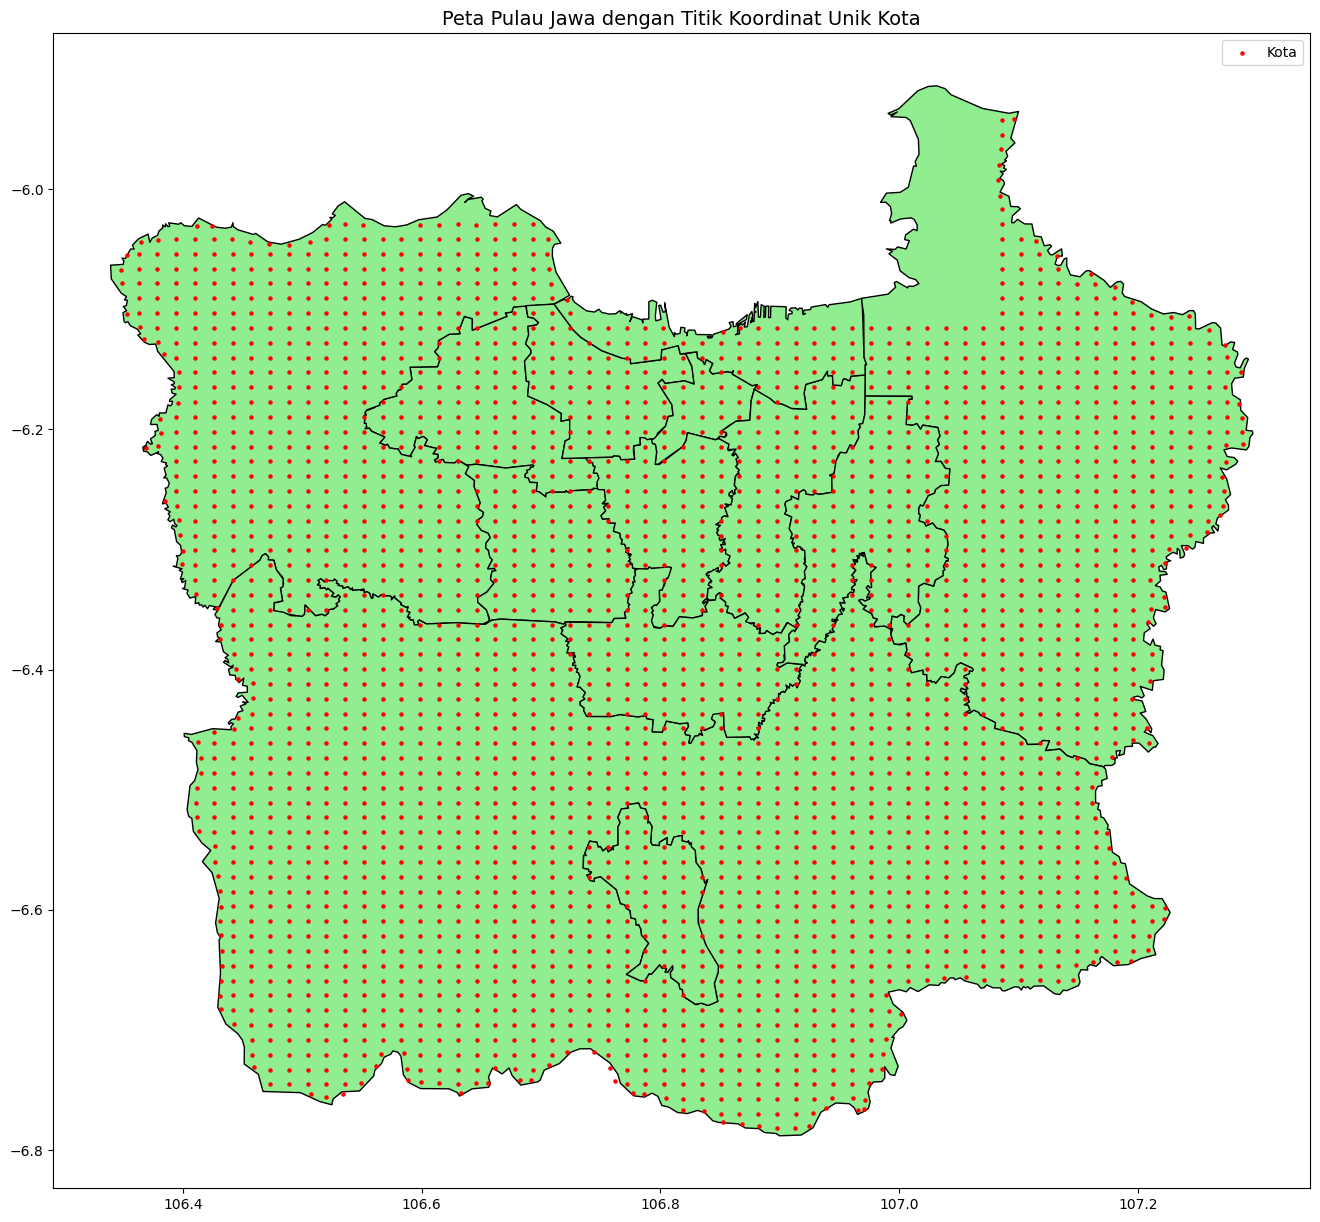

In [ ]:
# Load shapefile of Indonesia level-2
indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

# Create geometry column in df
merged_df['geometry'] = [Point(xy) for xy in zip(merged_df['x_coord'], merged_df['y_coord'])]
gdf = gpd.GeoDataFrame(merged_df, geometry='geometry', crs='EPSG:4326')


jawa_cities = ['Tangerang', 'KotaBogor','Bogor', 'KotaTangerang', 'JakartaUtara',
       'JakartaBarat', 'JakartaSelatan', 'JakartaPusat',
       'Depok', 'JakartaTimur', 'Bekasi', 'KotaBekasi','TangerangSelatan']
jawa = indonesia[indonesia['NAME_2'].isin(jawa_cities)]

# Plot peta Jawa
fig, ax = plt.subplots(figsize=(25, 15))
jawa.plot(ax=ax, color='lightgreen', edgecolor='black')


# Titik kota (kecuali "Sea") dan hapus duplikat koordinat
cities = gdf[gdf['city'] != 'Sea']
cities_unique = cities.drop_duplicates(subset=['x_coord', 'y_coord'])
cities_unique.plot(ax=ax, color='red', markersize=5, label='Kota')

# Tambahkan judul dan legenda
plt.title('Peta Pulau Jawa dengan Titik Koordinat Unik Kota', fontsize=14)
plt.legend()


plt.show()

In [ ]:
merged_df = merged_df[["date","CO_mean","u10","v10","x_coord","y_coord"]]

In [ ]:
merged_df.to_csv("/content/drive/My Drive/TA/Dataset/Localized/Preprocessed_Local_CO.csv")

In [ ]:
df = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/Preprocessed_Local_CO.csv",index_col=0)

In [ ]:
df['date'] = pd.to_datetime(df['date'])

## Teknik Rescaling

In [ ]:
#Convert to Numerical Value
df['time'] = (df['date'] - df['date'].min()).dt.days
scale = 1e-2
df.CO_mean = df.CO_mean/scale
df.x_coord = df.x_coord*100
df.y_coord = df.y_coord*100

## Lowpass Filtering dan Cek Normalitas Residu

In [ ]:
def low_pass_filter(series, cutoff=0.1):
    """Applies a low-pass filter to a pandas Series."""
    signal = series.values
    fft_vals = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), d=1) # d=1 assumes unit time spacing

    # Apply the ideal low-pass filter
    mask = np.abs(freqs) < cutoff
    filtered_fft = fft_vals * mask

    # Return the real part of the inverse FFT
    return np.fft.ifft(filtered_fft).real

full_dates = pd.date_range(start=df['date'].min(),end=df['date'].max(),freq='D')
df2 = (df.set_index('date').groupby(['x_coord', 'y_coord']).apply(lambda g: g.reindex(full_dates)).reset_index(level=[0,1]).rename_axis('date').reset_index())
df2['CO_mean'] = (df2.groupby(['x_coord', 'y_coord'])['CO_mean'].apply(lambda s: s.interpolate(method='linear', limit_direction='both')))
df['CO_filtered'] = df.groupby(['x_coord', 'y_coord'])['CO_mean'].transform(low_pass_filter)
df = df.merge(
    df[['date', 'x_coord', 'y_coord', 'CO_filtered']],
    on=['date', 'x_coord', 'y_coord'],
    how='left'
)

# 'df' now contains the new 'CO_filtered' column with the results.
print(df.head())

        date  CO_mean       u10       v10       x_coord     y_coord  time  \
0 2023-05-01   2.9764  0.129138 -0.205624  10636.297192 -606.604262     0   
1 2023-05-01   2.9764  0.129138 -0.205624  10636.297192 -607.839262     0   
2 2023-05-01   2.9764  0.129138 -0.205624  10636.297192 -605.369262     0   
3 2023-05-01   2.9764  0.129138 -0.205624  10636.297192 -609.074262     0   
4 2023-05-01   2.9764  0.122982 -0.205420  10636.297192 -610.309262     0   

   CO_filtered  
0     3.370741  
1     3.370741  
2     3.370741  
3     3.370741  
4     3.397441  


In [ ]:
df.describe()

,date,CO_mean,u10,v10,x_coord,y_coord,time,CO_filtered
count,1326813,1.326813e+06,1.326813e+06,1.326813e+06,1.326813e+06,1.326813e+06,1.326813e+06,1.326813e+06
mean,2024-03-26 00:28:48.373779456,3.484345e+00,-5.791124e-02,-5.763473e-02,1.068018e+04,-6.396099e+02,3.300200e+02,3.484345e+00
min,2023-05-01 00:00:00,1.393031e+00,-7.863542e-01,-4.133699e-01,1.063478e+04,-6.782034e+02,0.000000e+00,2.011518e+00
25%,2023-09-20 00:00:00,2.968940e+00,-1.479605e-01,-1.729378e-01,1.065988e+04,-6.560591e+02,1.420000e+02,3.022499e+00
50%,2024-03-31 00:00:00,3.378972e+00,-1.554030e-02,-3.664251e-02,1.068033e+04,-6.387143e+02,3.350000e+02,3.386949e+00
75%,2024-09-04 00:00:00,3.892701e+00,5.758766e-02,6.404804e-02,1.069920e+04,-6.226593e+02,4.920000e+02,3.854765e+00
max,2025-04-29 00:00:00,7.176243e+00,2.544336e-01,1.970594e-01,1.072882e+04,-5.941738e+02,7.290000e+02,6.517823e+00
std,NaN,7.148420e-01,1.879002e-01,1.328850e-01,2.400327e+01,1.978454e+01,2.069765e+02,6.328990e-01


In [ ]:
from scipy.stats import kstest
import pandas as pd


def check_normality(group):
    """
    Calculates KS test for normality on the residuals of a given group.
    """
    residuals = group['CO_mean'] - group['CO_filtered']
    std_residuals = residuals.std()

    # Handle cases where all residuals are the same
    if std_residuals == 0:
        return pd.Series({
            'Test Statistic (KS)': None,
            'P-value (KS)': None,
            'Normality (KS)': "Standard deviation is zero",
            'Data Points': len(residuals)
        })

    # Perform the KS test
    mean_residuals = residuals.mean()
    stat, p = kstest(residuals, 'norm', args=(mean_residuals, std_residuals))

    # Determine normality based on the p-value
    normality = "Gaussian" if p > 0.01 else "Not Gaussian"

    return pd.Series({
        'Test Statistic (KS)': stat,
        'P-value (KS)': p,
        'Normality (KS)': normality,
        'Data Points': len(residuals)
    })

# Group by coordinates only and apply the function
normality_results_df = df.groupby(['x_coord', 'y_coord']).apply(check_normality).reset_index()

# Display the first few rows of the results
print(normality_results_df.head())

        x_coord     y_coord  Test Statistic (KS)  P-value (KS) Normality (KS)  \
0  10634.777381 -606.702390             0.032164      0.755144       Gaussian   
1  10634.867379 -607.772079             0.032164      0.755144       Gaussian   
2  10635.274668 -610.351014             0.032164      0.755144       Gaussian   
3  10635.280286 -605.463514             0.032164      0.755144       Gaussian   
4  10636.297192 -606.604262             0.039037      0.455400       Gaussian   

   Data Points  
0          428  
1          428  
2          428  
3          428  
4          473  


/tmp/ipython-input-1252786904.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  normality_results_df = df.groupby(['x_coord', 'y_coord']).apply(check_normality).reset_index()


In [ ]:
normality_results_df["Normality (KS)"].value_counts()

,count
Normality (KS),
Gaussian,2861


In [ ]:
df.describe()

,date,CO_mean,u10,v10,x_coord,y_coord,time,CO_filtered
count,1326813,1.326813e+06,1.326813e+06,1.326813e+06,1.326813e+06,1.326813e+06,1.326813e+06,1.326813e+06
mean,2024-03-26 00:28:48.373779456,3.484345e+00,-5.791124e-02,-5.763473e-02,1.068018e+04,-6.396099e+02,3.300200e+02,3.484345e+00
min,2023-05-01 00:00:00,1.393031e+00,-7.863542e-01,-4.133699e-01,1.063478e+04,-6.782034e+02,0.000000e+00,2.011518e+00
25%,2023-09-20 00:00:00,2.968940e+00,-1.479605e-01,-1.729378e-01,1.065988e+04,-6.560591e+02,1.420000e+02,3.022499e+00
50%,2024-03-31 00:00:00,3.378972e+00,-1.554030e-02,-3.664251e-02,1.068033e+04,-6.387143e+02,3.350000e+02,3.386949e+00
75%,2024-09-04 00:00:00,3.892701e+00,5.758766e-02,6.404804e-02,1.069920e+04,-6.226593e+02,4.920000e+02,3.854765e+00
max,2025-04-29 00:00:00,7.176243e+00,2.544336e-01,1.970594e-01,1.072882e+04,-5.941738e+02,7.290000e+02,6.517823e+00
std,NaN,7.148420e-01,1.879002e-01,1.328850e-01,2.400327e+01,1.978454e+01,2.069765e+02,6.328990e-01


In [ ]:
averaged_df = df.groupby(['x_coord', 'y_coord'])[['u10', 'v10']].mean().reset_index()
df_for_update = df.drop(columns=['u10', 'v10'])
filtered_df = pd.merge(df_for_update, averaged_df, on=['x_coord', 'y_coord'], how='left')
filtered_df

,date,CO_mean,x_coord,y_coord,time,CO_filtered,u10,v10
0,2023-05-01,2.976400,10636.297192,-606.604262,0,3.370741,0.129138,-0.205624
1,2023-05-01,2.976400,10636.297192,-607.839262,0,3.370741,0.129138,-0.205624
2,2023-05-01,2.976400,10636.297192,-605.369262,0,3.370741,0.129138,-0.205624
3,2023-05-01,2.976400,10636.297192,-609.074262,0,3.370741,0.129138,-0.205624
4,2023-05-01,2.976400,10636.297192,-610.309262,0,3.397441,0.122982,-0.205420
...,...,...,...,...,...,...,...,...
1326808,2025-04-29,2.958721,10728.462797,-617.876784,729,2.992541,-0.534941,-0.285329
1326809,2025-04-29,2.958721,10728.629908,-615.196405,729,2.992541,-0.534941,-0.285329
1326810,2025-04-29,2.958721,10728.702147,-619.031537,729,2.992541,-0.534941,-0.285329
1326811,2025-04-29,3.033131,10728.771896,-620.242884,729,3.216166,-0.533784,-0.265644


In [ ]:
filtered_df.describe()

,date,CO_mean,x_coord,y_coord,time,CO_filtered,u10,v10
count,1326813,1.326813e+06,1.326813e+06,1.326813e+06,1.326813e+06,1.326813e+06,1.326813e+06,1.326813e+06
mean,2024-03-26 00:28:48.373779456,3.484345e+00,1.068018e+04,-6.396099e+02,3.300200e+02,3.484345e+00,-5.791124e-02,-5.763473e-02
min,2023-05-01 00:00:00,1.393031e+00,1.063478e+04,-6.782034e+02,0.000000e+00,2.011518e+00,-7.863542e-01,-4.133699e-01
25%,2023-09-20 00:00:00,2.968940e+00,1.065988e+04,-6.560591e+02,1.420000e+02,3.022499e+00,-1.479605e-01,-1.729378e-01
50%,2024-03-31 00:00:00,3.378972e+00,1.068033e+04,-6.387143e+02,3.350000e+02,3.386949e+00,-1.554030e-02,-3.664251e-02
75%,2024-09-04 00:00:00,3.892701e+00,1.069920e+04,-6.226593e+02,4.920000e+02,3.854765e+00,5.758766e-02,6.404804e-02
max,2025-04-29 00:00:00,7.176243e+00,1.072882e+04,-5.941738e+02,7.290000e+02,6.517823e+00,2.544336e-01,1.970594e-01
std,NaN,7.148420e-01,2.400327e+01,1.978454e+01,2.069765e+02,6.328990e-01,1.879002e-01,1.328850e-01


# Split Train Testing

In [ ]:
np.random.seed(42)


shuffled_df = filtered_df.sample(frac=1).reset_index(drop=True)

split_ratio = 0.7

# Calculate the number of training samples
train_size = int(split_ratio * len(shuffled_df))

# Split the data
train_df = shuffled_df[:train_size]
test_df = shuffled_df[train_size:]

# Convert to tensors
X_train = tf.convert_to_tensor(train_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_train =  tf.convert_to_tensor(train_df['CO_filtered'].values.reshape(-1, 1), dtype= tf.float32)

X_test =  tf.convert_to_tensor(test_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_test =  tf.convert_to_tensor(test_df['CO_filtered'].values.reshape(-1, 1), dtype= tf.float32)

W_u =tf.convert_to_tensor(train_df[[ 'u10']].values, dtype= tf.float32)
W_v =tf.convert_to_tensor(train_df[['v10']].values, dtype= tf.float32)

In [ ]:
X_train

<tf.Tensor: shape=(928769, 3), dtype=float32, numpy=
array([[   88.     , 10688.189  ,  -612.77924],
       [  566.     , 10716.495  ,  -610.30927],
       [  439.     , 10714.605  ,  -665.8574 ],
       ...,
       [  112.     , 10716.053  ,  -607.03186],
       [   99.     , 10667.747  ,  -647.35925],
       [  729.     , 10722.785  ,  -617.71924]], dtype=float32)>

In [ ]:
X_test

<tf.Tensor: shape=(398044, 3), dtype=float32, numpy=
array([[  448.     , 10713.35   ,  -628.8343 ],
       [  249.     , 10658.3125 ,  -646.12427],
       [  288.     , 10642.818  ,  -634.85065],
       ...,
       [   61.     , 10644.16   ,  -618.9543 ],
       [  339.     , 10652.022  ,  -628.8343 ],
       [   57.     , 10680.327  ,  -638.71423]], dtype=float32)>

In [ ]:
u_train

<tf.Tensor: shape=(928769, 1), dtype=float32, numpy=
array([[4.016969 ],
       [3.2147849],
       [2.953204 ],
       ...,
       [3.4061174],
       [3.875674 ],
       [3.024418 ]], dtype=float32)>

In [ ]:
u_test

<tf.Tensor: shape=(398044, 1), dtype=float32, numpy=
array([[3.3329265],
       [3.261877 ],
       [3.2003546],
       ...,
       [3.4469466],
       [3.1565864],
       [3.674022 ]], dtype=float32)>

In [ ]:
W_u

<tf.Tensor: shape=(928769, 1), dtype=float32, numpy=
array([[-0.38666815],
       [-0.58250654],
       [ 0.01500524],
       ...,
       [-0.5667542 ],
       [ 0.05758766],
       [-0.39999828]], dtype=float32)>

In [ ]:
W_v

<tf.Tensor: shape=(928769, 1), dtype=float32, numpy=
array([[-0.30968702],
       [-0.27747717],
       [-0.06178088],
       ...,
       [-0.28159213],
       [ 0.07013614],
       [-0.1878103 ]], dtype=float32)>

# Persiapan PINN

## Persiapan Arsitektur PINN

In [ ]:
lb = filtered_df[['time','x_coord', 'y_coord']].min().values
ub = filtered_df[['time','x_coord', 'y_coord']].max().values

In [ ]:
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'tanh', 'trainable_B':True, 'sigmas':[1,2], 'mapping_size':64}
n_models = 20

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = Hybrid_IdentificationNet(initial_lambda=0.0, lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

## Persiapan Automatic Differentiation dan Fungsi Loss

### Inverse Method

In [ ]:
def get_r_inv(t, x, y, model, lambd, fun_r,u_data=u_train):
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.cast(t, tf.float32)
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2

    return fun_r(t, x, y, u_pred, u_t, u_x,u_y, u_xx, u_yy, model)

def fun_r_inv(t, x, y, u_pred, u_t,u_x,u_y, u_xx, u_yy, model, u_data= u_train):
    # # --- Calculate the Gaussian source term ---
    # term_x = tf.square(x - model.source_x0) / (2 * tf.square(model.source_sigma_x))
    # term_y = tf.square(y - model.source_y0) / (2 * tf.square(model.source_sigma_y))
    # gaussian_source = model.source_A * tf.exp(-(term_x + term_y))
    # # ---
    # This function is used in the forward pass loss calculation, where W_u and W_v are global
    # This might still cause issues if not careful about batching in the forward pass.
    pde_residual = scale*(u_t + W_u * u_x + W_v * u_y- model.lambd * (u_xx + u_yy))
    return tf.reduce_mean(tf.square(pde_residual))

def get_r_param(t, x, y, Wu, Wv, model):
    t = tf.cast(t, tf.float32)
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)
    Wu = tf.cast(Wu, tf.float32)
    Wv = tf.cast(Wv, tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)

    del tape
    del tape2

    # # ---
    # term_x = tf.square(x - model.source_x0) / (2 * tf.square(model.source_sigma_x))
    # term_y = tf.square(y - model.source_y0) / (2 * tf.square(model.source_sigma_y))
    # gaussian_source = model.source_A * tf.exp(-(term_x + term_y))
    # # ---
    with tf.GradientTape(persistent=True) as tape_lambd:
      tape_lambd.watch(model.lambd)
      pde_residual = scale*(u_t) +scale* Wu * u_x + scale*Wv * u_y- model.lambd * (scale*u_xx + scale*u_yy)

      loss = tf.reduce_mean(tf.square(pde_residual))

    g = tape_lambd.gradient(loss, model.lambd)

    del tape_lambd

    return loss, g

### Forward Method

In [ ]:
def get_r_fwd(t, x, y, model, lambd, fun_r,u_data=u_train, Wu=W_u, Wv=W_v): # Added Wu and Wv here
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.convert_to_tensor(t, dtype=tf.float32)
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    y = tf.convert_to_tensor(y, dtype=tf.float32)
    # Ensure Wu and Wv are tensors if not None
    if Wu is not None:
        Wu = tf.convert_to_tensor(Wu, dtype=tf.float32)
    if Wv is not None:
        Wv = tf.convert_to_tensor(Wv, dtype=tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)
            u = model(tf.concat([t, x,y], axis=1))  # Ensure proper tensor shape
        u_t = tape2.gradient(u, t)
        u_x = tape2.gradient(u, x)
        u_y = tape2.gradient(u, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2
    return fun_r_fwd(t, x, y, u, u_t,u_x,u_y,u_xx, u_yy, model,lambd,u_data, Wu=Wu, Wv=Wv) # Pass Wu and Wv here

def fun_r_fwd(t, x, y, u, u_t,u_x,u_y, u_xx, u_yy, model,lambd, u_data= u_train, weight_pde=1, weight_data=10, Wu=W_u, Wv=W_v): # Added Wu and Wv here
    if Wu is None or Wv is None:
        print("Warning: Wu or Wv is None in fun_r_fwd")

    pde_residual = scale*(u_t) +scale* Wu * u_x + scale*Wv * u_y- lambd * (scale*u_xx + scale*u_yy)
    pde_loss = tf.reduce_mean(tf.square(pde_residual))

    u_pred_data = u
    data_loss = tf.reduce_mean(tf.square((u_pred_data - u_data)))

    total_loss = weight_pde * pde_loss + weight_data*data_loss
    tf.print("PDE Loss:", pde_loss, "Data Loss:",data_loss, "Total Loss:", total_loss)
    return total_loss

# Pelatihan Invers

In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

In [ ]:
timeout = 300
initial_lambdas = [0.5]
batch_size = 4096 # Define a suitable batch size

old_timeout = timeout
models_Adam = [None] * n_models
hists_Adam = [None] * n_models

for i in range(n_models):
  timeout = old_timeout
  models_Adam[i] = []
  hists_Adam[i] = []

  for j in range(len(initial_lambdas)):
    print('{:s}\nIteration: {:d} Initial lambda: {}\n{:s}'.format(50*'-',i+1,initial_lambdas[j],50*'-'))
    # Prepare models' architecture
    tf.random.set_seed(i + j)
    models_Adam[i].append(Hybrid_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch))

    models_Adam[i][j].build((None, 3))

    # Copy weights from the previous model instance to make every iteration comparable
    models_Adam[i][j].set_weights(models[i].get_weights())

    # Assigning initial lambda
    # models_Adam[i][j].trainable_variables[-1].assign(initial_lambdas[j])
    models_Adam[i][j].initial_lambda = initial_lambdas[j]

    # Prepare optimizer
    optim_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)
    optim_inv_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)

    # Initialize solver
    solver_Adam = Hybrid_IdentificationSolver(models_Adam[i][j], X_train,fun_r_inv, get_r_inv)

    # Train models
    print('\n\nAdam\n')
    solver_Adam.solve_with_TFoptimizer(optim_Adam, optim_inv_Adam, get_r_param, X_train, u_train, W_u, W_v, timeout_param=timeout*0.2, timeout_fwd=timeout*0.8, batch_size=batch_size)

    # Store evolution of lambdas and hists
    hists_Adam[i].append([models_Adam[i][j].lambd_list, solver_Adam.hist])

    print('\n\n\n')

--------------------------------------------------
Iteration: 1 Initial lambda: 0.5
--------------------------------------------------


Adam



/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['Variable:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


--- End of Epoch 1, Iteration 1, Average Epoch Loss: 5.508730e-01 ---
--- End of Epoch 2, Iteration 2, Average Epoch Loss: 7.131479e-02 ---


KeyboardInterrupt: 

In [ ]:
path = dir + "COModel/Fourier/Local_Fourier_tanh_inv/"


In [ ]:
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    models_Adam[i][j].save_weights(path+"_"+str(i+60)+"_model_Adam_"+str(j)+".weights.h5", 'h5')
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/hist_Adam_" + str(i+60) + "_" + str(j) + ".csv", hists_Adam[i][j][1], delimiter=",")

for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/lambd_Adam_" + str(i+60) + "_" + str(j) + ".csv", hists_Adam[i][j][0], delimiter=",")

In [ ]:
n_models=60
hists_Adam1 = [None] * n_models
lambd_Adam1 = [None] * n_models

for i in range(60, 60+n_models):
    hists_Adam1[i-60] = []
    lambd_Adam1[i-60]=[]
    for j in range(len(initial_lambdas)):
        hists_Adam1[i-60].append(pd.read_csv(path + "/loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())
        lambd_Adam1[i-60].append(pd.read_csv(path + "/loss/lambd_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())

## Grafik Loss

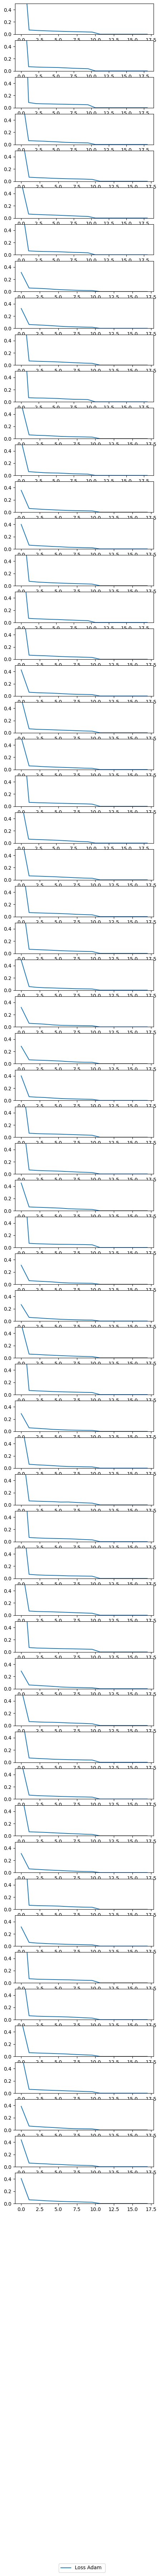

In [ ]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(5,80))

# fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(15,5))

for i in range(n_models):
  axes[i].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  axes[i].set_ylim([0,5e-1])

  # axes[0].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  # axes[0].set_ylim([0,5])

  # axes[1].plot(np.linspace(0, len(hists_Adam1[i][1].transpose()), len(hists_Adam1[i][1].transpose())), hists_Adam1[i][1].transpose())
  # axes[1].set_ylim([0,5])

  # axes[2].plot(np.linspace(0, len(hists_Adam1[i][2].transpose()), len(hists_Adam1[i][2].transpose())), hists_Adam1[i][2].transpose())
  # axes[2].set_ylim([0,5])


  # print(f"len Atempt-{i} and init lambda {initial_lambdas[0]}: ",len(hists_Adam1[i][0].transpose()))
  # print(f"len Atempt-{i} and init lambda {initial_lambdas[1]}: ",len(hists_Adam1[i][1].transpose()))
  # print(f"len Atempt-{i} and init lambda {initial_lambdas[2]}: ",len(hists_Adam1[i][2].transpose()))
  # print(f"len Atempt-{i} and init lambda {initial_lambdas[3]}: ",len(hists_Adam1[i][3].transpose()))

# timeout = 250
cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

# pad = 5 # in points


# for ax, col in zip(axes[0], cols):
#   ax.annotate(col, xy=(0.5, 1.05), xytext=(0, pad),
#               xycoords='axes fraction', textcoords='offset points',
#               size='large', ha='center', va='baseline')

# for ax, row in zip(axes[:,0], rows):
#   ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
#               xycoords=ax.yaxis.label, textcoords='offset points',
#               size='large', ha='right', va='center')

# fig.tight_layout()

fig.legend(['Loss Adam '], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

## Predict and Evaluate Inverse Problem

In [ ]:
def lambdas(hists, iter_model, iter_init):
  return lambd_Adam1[i][0].transpose().iloc[-1,:].values[0]

df = pd.DataFrame(columns=['Adam'])
df = df.round(10)

for i in range(n_models):
  x = []
  for j in range(len(initial_lambdas)):
    x.append(lambdas(hists_Adam1, i, j))

  df.loc['Attempt '+str(i+1)] = x

print("Lambda Prediction Given U(x,t)")
df

Lambda Prediction Given U(x,t)


,Adam
Attempt 1,0.324910
Attempt 2,0.393015
Attempt 3,0.348151
Attempt 4,0.248777
Attempt 5,0.372669
Attempt 6,0.169669
Attempt 7,0.355629
Attempt 8,0.260672
Attempt 9,0.323101
Attempt 10,0.387578


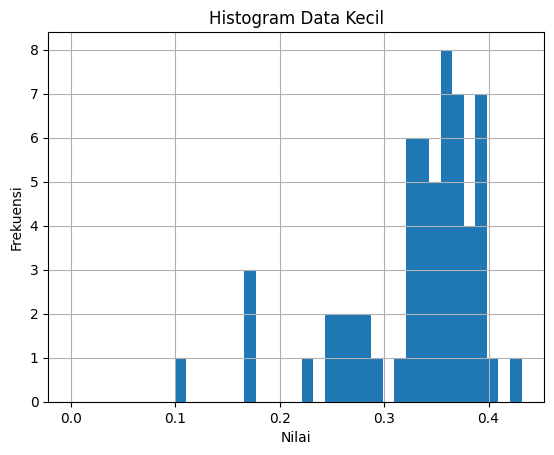

In [ ]:
bins = np.linspace(0, max(df.Adam), 40)  # 20 bins antara 0 dan 0.0001
ax = df.iloc[:, 0].plot(kind='hist', bins=bins, align='mid')

plt.xlabel("Nilai")
plt.ylabel("Frekuensi")
plt.title("Histogram Data Kecil")
plt.grid(True)
plt.show()

burr         KS=0.0715, p=0.8976, params=(np.float64(12089.608921305276), np.float64(0.1444191788062102), np.float64(-107.12460526476094), np.float64(107.515586033233))
fisk         KS=0.1424, p=0.1592, params=(np.float64(395130052.01073444), np.float64(-13760486.718124492), np.float64(13760487.05928429))
gengamma     KS=0.1798, p=0.03615, params=(np.float64(58.56301906881771), np.float64(5.836935251917769), np.float64(-2.4621557959079174), np.float64(1.3927644289367125))
norm         KS=0.1862, p=0.02713, params=(np.float64(0.3315050172309081), np.float64(0.06459849388384911))
lognorm      KS=0.1862, p=0.02712, params=(np.float64(8.235687702450728e-06), -7843.443477674627, np.float64(7843.774982425846))
gamma        KS=0.1988, p=0.01487, params=(np.float64(224.77130672089578), np.float64(-0.6884969865655579), np.float64(0.004537281070519702))
beta         KS=0.2205, p=0.004821, params=(np.float64(2.3413421207759564), np.float64(0.8762682412706226), np.float64(0.04961854499172737), np.

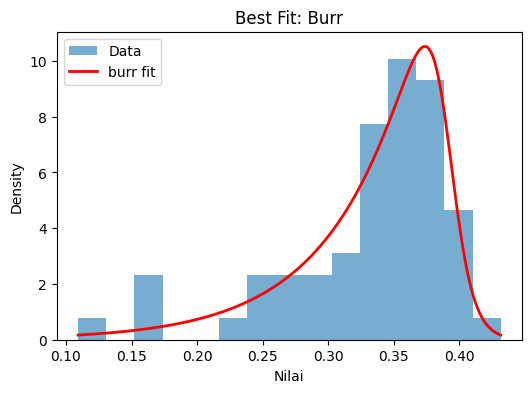

Mean Burr: 0.33135199344467026


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# If df is a DataFrame, pick the column you want to fit:
data = df.iloc[:, 0].to_numpy()  # 1D array

distributions = [
    stats.norm,          # Normal
    stats.expon,         # Exponential
    stats.gamma,         # Gamma
    stats.beta,          # Beta
    stats.lognorm,       # Lognormal
    stats.uniform,       # Uniform
    stats.invgauss,      # Inverse Gaussian
    stats.burr,          # Burr
    stats.fisk,          # Fisk (log-logistic)
    stats.gengamma       # Generalized Gamma
]

results = {}

# Fit tiap distribusi dan uji KS
for dist in distributions:
    try:
        params = dist.fit(data)
        ks_stat, ks_pval = stats.kstest(data, dist.cdf, args=params)
        results[dist.name] = {
            "KS_stat": float(ks_stat),
            "p_value": float(ks_pval),
            "params": params
        }
    except Exception as e:
        results[dist.name] = {"KS_stat": np.inf, "p_value": 0, "params": None}
        print(f"Gagal fit {dist.name}: {e}")

# Urutkan dari KS terkecil
sorted_results = sorted(results.items(), key=lambda x: x[1]["KS_stat"])

# Tampilkan hasil
for name, res in sorted_results:
    if res["params"] is not None:
        print(f"{name:12s} KS={res['KS_stat']:.4f}, p={res['p_value']:.4g}, params={res['params']}")

# Plot best fit
best_name, best_info = sorted_results[0]
best_dist = getattr(stats, best_name)
params = best_info["params"]

x = np.linspace(min(data), max(data), 200)
pdf = best_dist.pdf(x, *params)

plt.figure(figsize=(6,4))
plt.hist(data, bins=15, density=True, alpha=0.6, label="Data")
plt.plot(x, pdf, 'r-', lw=2, label=f"{best_name} fit")
plt.title(f"Best Fit: {best_name.capitalize()}")
plt.xlabel("Nilai")
plt.ylabel("Density")
plt.legend()
plt.show()

params = stats.burr.fit(data)
c, d, loc, scale = params
mean_burr = stats.burr.mean(c, d, loc=loc, scale=scale)
print("Mean Burr:", mean_burr)

In [ ]:
print(df.mean(axis=0).round(10))
df.loc['Average'] = df.mean(axis=0)
df.loc['StdDev'] = df.std(axis=0, ddof=1)
df.loc['CV'] = df.loc['StdDev'] / df.loc['Average']
df.loc[['Average', 'StdDev', 'CV']] = df.loc[['Average', 'StdDev', 'CV']].round(10)
print(df.tail(3))

Adam    0.331505
dtype: float64
             Adam
Average  0.331505
StdDev   0.064598
CV       0.194864


# Pelatihan Kasus Forward

In [ ]:
n_models = 2

arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'tanh', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = PINN_NeuralNet(lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_2', however 

In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

Text(0.5, 1, 'Combined Learning Rate')

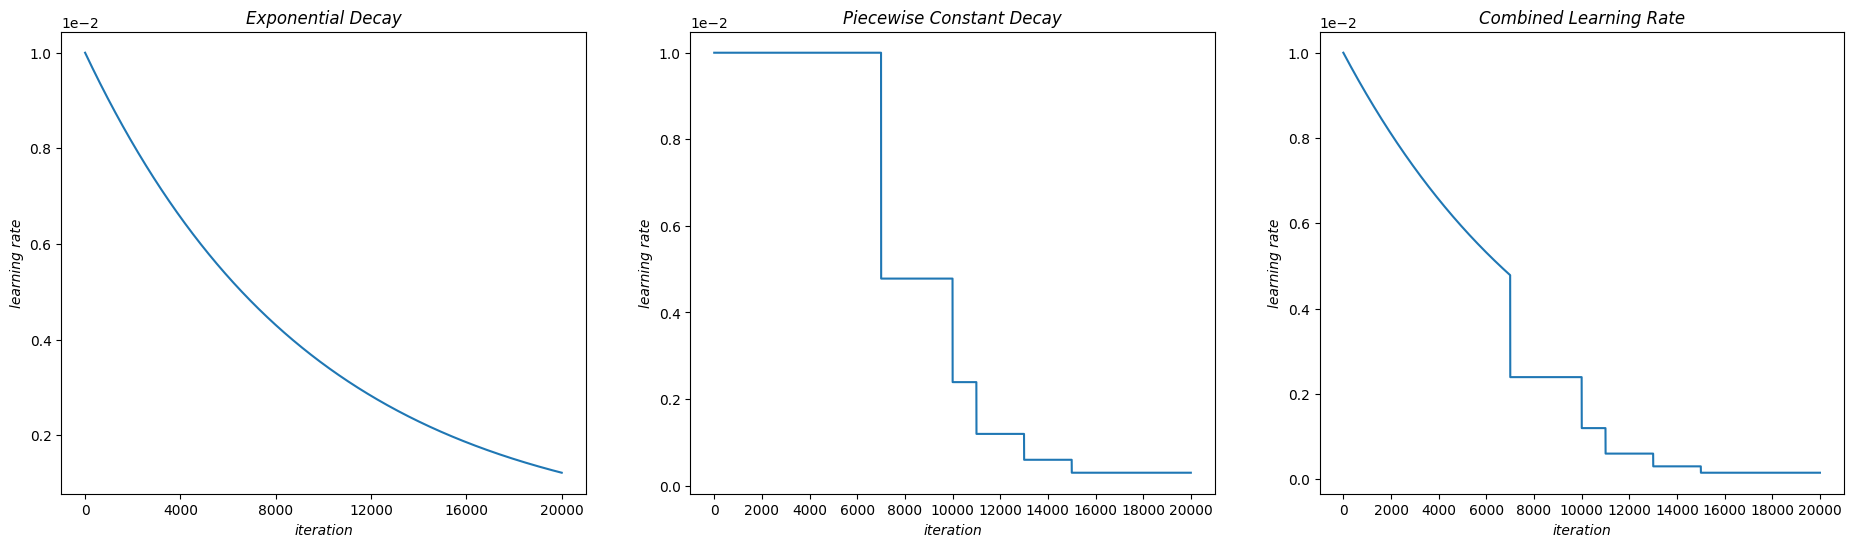

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 20000  # Extended range

fig = plt.figure(figsize=(23, 6))

# ExponentialDecay
initial_learning_rate = lr_comb.initial_learning_rate
decay_steps = lr_comb.decay_steps
decay_rate = lr_comb.decay_rate

learning_rate = []
for i in range(N+1):
    lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    learning_rate.append(lr)

plt.subplot(1, 3, 1)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 4000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Exponential Decay', y=1, fontstyle='italic')

# Piecewise Constant Decay
boundaries = lr_comb.boundaries
values = lr_comb.values

learning_rate = []
for i in range(N+1):
    for j in range(len(boundaries)):
        if i <= boundaries[0]:
            lr = lr_comb.initial_learning_rate
        elif i <= boundaries[j]:
            lr = values[j-1]
            break
        else:
            lr = values[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 2)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Piecewise Constant Decay', y=1, fontstyle='italic')

# Extended Combined Decay
boundaries = lr_comb.boundaries
values_steps = lr_comb.values_steps  # should be a list like [2, 2, 2, ...]
if isinstance(values_steps, int):
    values_steps = [values_steps] * (len(boundaries))  # Make uniform if scalar

i_stop = boundaries[0]
learning_rate = []

learning_rate = []
i_stop = boundaries[0]

for i in range(N+1):
    if i <= i_stop:
        lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    else:
        for j in range(1, len(boundaries)):
            if boundaries[j-1] < i <= boundaries[j]:
                if i == boundaries[j-1] + 1:
                    # first step into this boundary: decay from previous segment
                    prev_lr = learning_rate[-1]
                    lr = prev_lr / values_steps[j-1]
                else:
                    lr = learning_rate[-1]  # maintain constant
                break
        else:
            # After the last boundary
            lr = learning_rate[-1] / values_steps[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 3)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0,0))
plt.title('Combined Learning Rate', y=1, fontstyle='italic')



In [ ]:
pred_lambda = [0.33135199344467026]
# pred_lambda = [3.6534748e-05]

In [ ]:
timeout = 1200
start_from = 1


models_Adam_comb = [None]*n_models
hists_Adam_comb = [None]*n_models
batch_size = 4096

for i in range(start_from - 1, n_models):
    models_Adam_comb[i] = []
    hists_Adam_comb[i] = []
    for j, lambd_val in enumerate(pred_lambda):
        print('{:s}\nModel Iteration: {:d}, Lambda Iteration: {:d}\n{:s}'.format(
            50*'-', i+1, j+1, 50*'-'))

        tf.random.set_seed(i + j)  # Use a combined seed for reproducibility

        # Build and initialize model
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))

        # Set weights and lambda from base model
        models_Adam_comb[i][j].set_weights(models[i].get_weights())
        # Prepare optimizer
        optim_Adam_comb = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay =1e-3)

        # Initialize solver
        solver = PINN_PDESolver(models_Adam_comb[i][j], X_train, fun_r_fwd, get_r_fwd,lambd_val)

        # Train the model
        print('\n\nAdam - Combined Learning Rate\n')
        solver.solve_with_TFoptimizer(optim_Adam_comb, X_train, u_train, W_u, W_v,timeout=timeout,batch_size=batch_size)

        # Store training history
        hists_Adam_comb[i].append(solver.hist)

        print('\n\n\n')

--------------------------------------------------
Model Iteration: 1, Lambda Iteration: 1
--------------------------------------------------


Adam - Combined Learning Rate



/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
PDE Loss: 0.345621616 Data Loss: 0.112031162 Total Loss: 1.4659332
PDE Loss: 0.329947114 Data Loss: 0.10407874 Total Loss: 1.37073457
PDE Loss: 0.332801104 Data Loss: 0.105763257 Total Loss: 1.39043367
PDE Loss: 0.338774055 Data Loss: 0.102152549 Total Loss: 1.36029959
PDE Loss: 0.317387402 Data Loss: 0.103982806 Total Loss: 1.3572154
PDE Loss: 0.313436985 Data Loss: 0.106999829 Total Loss: 1.38343525
PDE Loss: 0.32688266 Data Loss: 0.0990374833 Total Loss: 1.3172574
PDE Loss: 0.344961792 Data Loss: 0.105889194 Total Loss: 1.40385365
PDE Loss: 0.28433308 Data Loss: 0.107489653 Total Loss: 1.35922968
PDE Loss: 0.293159485 Data Loss: 0.10765557 Total Loss: 1.36971521
PDE Loss: 0.328395158 Data Loss: 0.107285976 Total Loss: 1.40125489
PDE Loss: 0.371038496 Data Loss: 0.101857051 Total Loss: 1.3896091
PDE Loss: 0.378268808 Data Loss: 0.100317962 Total Loss: 1.38144851
PDE Loss: 0.301963329 Data Loss: 0.106067903 Total Loss: 1.36264241
PDE 

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_7', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
PDE Loss: 0.341114134 Data Loss: 0.101637676 Total Loss: 1.3574909
PDE Loss: 0.347368538 Data Loss: 0.103482626 Total Loss: 1.38219476
PDE Loss: 0.357415318 Data Loss: 0.108092785 Total Loss: 1.43834317
PDE Loss: 0.331956983 Data Loss: 0.102402188 Total Loss: 1.35597885
PDE Loss: 0.307313621 Data Loss: 0.109230064 Total Loss: 1.39961433
PDE Loss: 0.34046188 Data Loss: 0.102244921 Total Loss: 1.36291111
PDE Loss: 0.339312047 Data Loss: 0.101423904 Total Loss: 1.35355115
PDE Loss: 0.321261197 Data Loss: 0.106020428 Total Loss: 1.38146544
PDE Loss: 0.313936055 Data Loss: 0.100491881 Total Loss: 1.31885481
PDE Loss: 0.346425474 Data Loss: 0.1037229 Total Loss: 1.38365459
PDE Loss: 0.366058707 Data Loss: 0.0993591398 Total Loss: 1.35965014
PDE Loss: 0.333033323 Data Loss: 0.101014189 Total Loss: 1.34317517
PDE Loss: 0.291149765 Data Loss: 0.100797765 Total Loss: 1.29912734
PDE Loss: 0.31900844 Data Loss: 0.102303654 Total Loss: 1.34204495
P

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_8', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
PDE Loss: 0.333136588 Data Loss: 0.100025147 Total Loss: 1.33338809
PDE Loss: 0.332973897 Data Loss: 0.10497696 Total Loss: 1.3827436
PDE Loss: 0.291606337 Data Loss: 0.111284919 Total Loss: 1.40445554
PDE Loss: 0.310436219 Data Loss: 0.105204701 Total Loss: 1.36248326
PDE Loss: 0.375249863 Data Loss: 0.104560256 Total Loss: 1.42085242
PDE Loss: 0.392028749 Data Loss: 0.097980909 Total Loss: 1.37183785
PDE Loss: 0.351750016 Data Loss: 0.101340435 Total Loss: 1.36515439
PDE Loss: 0.320232272 Data Loss: 0.104877464 Total Loss: 1.36900687
PDE Loss: 0.295351863 Data Loss: 0.108376 Total Loss: 1.37911189
PDE Loss: 0.323765308 Data Loss: 0.104984425 Total Loss: 1.37360954
PDE Loss: 0.344522357 Data Loss: 0.105184272 Total Loss: 1.39636505
PDE Loss: 0.349943399 Data Loss: 0.0988198072 Total Loss: 1.33814144
PDE Loss: 0.370590299 Data Loss: 0.105672643 Total Loss: 1.42731678
PDE Loss: 0.323680341 Data Loss: 0.106578074 Total Loss: 1.38946104
P

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_9', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


PDE Loss: 0.169553012 Data Loss: 10.3679504 Total Loss: 103.84906
PDE Loss: 1.76544476 Data Loss: 2.46514845 Total Loss: 26.4169312
PDE Loss: 6.51709 Data Loss: 81.7558136 Total Loss: 824.075195
PDE Loss: 0.104053058 Data Loss: 4.09331703 Total Loss: 41.0372238
PDE Loss: 0.163844988 Data Loss: 2.05577302 Total Loss: 20.7215748
PDE Loss: 0.057021603 Data Loss: 1.59069049 Total Loss: 15.9639263
PDE Loss: 0.0342379659 Data Loss: 0.644443691 Total Loss: 6.47867489
PDE Loss: 0.0492370352 Data Loss: 1.7814647 Total Loss: 17.863884
PDE Loss: 0.0508487448 Data Loss: 0.951132715 Total Loss: 9.56217575
PDE Loss: 0.043327678 Data Loss: 0.386543512 Total Loss: 3.90876269
PDE Loss: 0.0483869687 Data Loss: 0.979834735 Total Loss: 9.84673405
PDE Loss: 0.0446083583 Data Loss: 0.973108947 Total Loss: 9.77569771
PDE Loss: 0.0415260717 Data Loss: 0.443998575 Total Loss: 4.48151159
PDE Loss: 0.036843013 Data Loss: 0.396705985 Total Loss: 4.00390291
PDE Loss: 0.0309051275 Data Loss: 0.700056255 Total Loss:

KeyboardInterrupt: 

In [ ]:
path = dir + "COModel/Fourier/Local_Fourier_tanh_fwd/"

In [ ]:
n_models=2

In [ ]:
for i in range(n_models):
  for j in range(len(pred_lambda)):
    models_Adam_comb[i][j].save_weights(path+"_"+str(i)+"_model_Adam_comb_"+str(j)+".weights.h5", 'h5')


for i in range(n_models):
  for j in range(len(pred_lambda)):
    np.savetxt(path + "loss/hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv", hists_Adam_comb[i][j], delimiter=",")

In [ ]:
path

'/content/drive/My Drive/TA/COModel/Fourier/Local_Fourier_tanh_fwd/'

In [ ]:
n_models = 5


arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'tanh', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = PINN_NeuralNet(lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

models_Adam_comb = [None]*n_models # Initialize models_Adam_comb with the correct size

for i in range(0, n_models):
    models_Adam_comb[i] = []
    for j in range(len(pred_lambda)):
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))
        _ = models_Adam_comb[i][j](tf.zeros((1, 3)))
        models_Adam_comb[i][j].load_weights(
            path + "_" + str(i) + "_model_Adam_comb_" + str(j) + ".weights.h5"
        )


hists_Adam_comb = [None] * n_models

for i in range(0,n_models):
    hists_Adam_comb[i] = []
    for j in range(len(pred_lambda)):
        hists_Adam_comb[i].append(pd.read_csv(path + "/loss/hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_45', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_46', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_47', how

In [ ]:
models_Adam_comb

[[<PINN_NeuralNet name=pinn__neural_net_50, built=True>],
 [<PINN_NeuralNet name=pinn__neural_net_51, built=True>],
 [<PINN_NeuralNet name=pinn__neural_net_52, built=True>],
 [<PINN_NeuralNet name=pinn__neural_net_53, built=True>],
 [<PINN_NeuralNet name=pinn__neural_net_54, built=True>]]

In [ ]:
# Reshape each DataFrame in the list
hists_Adam_comb[0] = [hist.values.reshape(-1, 1) for hist in hists_Adam_comb[0]]
hists_Adam_comb[1] = [hist.values.reshape(-1, 1) for hist in hists_Adam_comb[1]]


## Grafik Loss

len Atempt-0 Lambda ke- 0:  40
\\
len Atempt-1 Lambda ke- 0:  40
\\
len Atempt-2 Lambda ke- 0:  41
\\
len Atempt-3 Lambda ke- 0:  41
\\
len Atempt-4 Lambda ke- 0:  41
\\


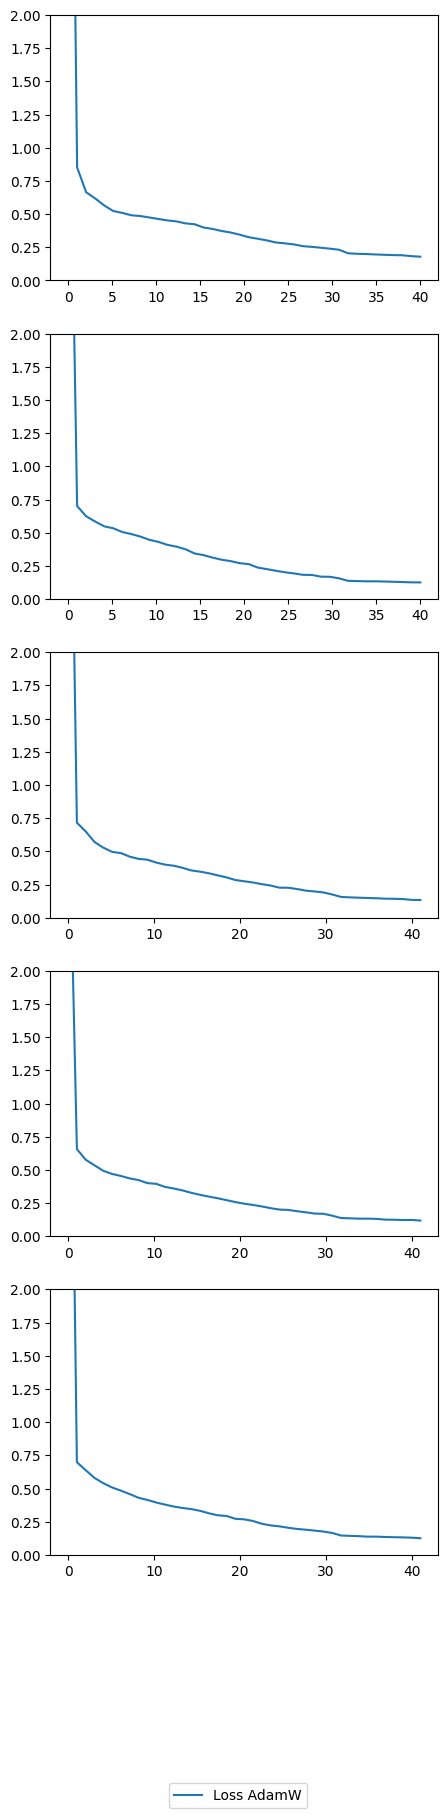

In [ ]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(pred_lambda), figsize=(5,20))

for i in range(n_models):
  for j in range(len(pred_lambda)):
    axes[i].plot(np.linspace(0, len(hists_Adam_comb[i][0]),len(hists_Adam_comb[i][0])), hists_Adam_comb[i][0])
    axes[i].set_ylim([0,2])
  # for j in range(len(pred_lambda)):
  #   axes[j].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
  #   axes[j].set_ylim([0,5e4])


    print(f"len Atempt-{i} Lambda ke- {j}: ",len(hists_Adam_comb[i][j]))
  print("\\\\")

  rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

fig.legend(['Loss AdamW'], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

## Prediction and Evaluation

In [ ]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())


In [ ]:
lb = tf.constant(lb, dtype=tf.float32)
ub = tf.constant(ub, dtype=tf.float32)

In [ ]:
train_Adam_comb = []


t_unique_train = np.sort(train_df['time'].unique())
x_unique_train = np.sort(train_df['x_coord'].unique())
y_unique_train = np.sort(train_df['y_coord'].unique())


for i in range(n_models):
  for j in range(len(pred_lambda)):
    train_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_train, t_unique_train, x_unique_train, y_unique_train))


df = pd.DataFrame(columns=['Adam'])
initial_lambdas = pred_lambda

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = train_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_train.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam
Attempt 1,"(0.102548085, 2.968128)"
Attempt 2,"(0.08763933, 2.53805)"
Attempt 3,"(0.08959226, 2.6341383)"
Attempt 4,"(0.083507404, 2.4485204)"
Attempt 5,"(0.08492191, 2.4977467)"


In [ ]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())

preds_Adam_comb = []

for i in range(n_models):
  for j in range(len(pred_lambda)):
    preds_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_test, t_unique, x_unique, y_unique))


In [ ]:
df = pd.DataFrame(columns=['Adam'])
initial_lambdas = pred_lambda

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = preds_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_test.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam
Attempt 1,"(0.10291972, 2.9786408)"
Attempt 2,"(0.08816186, 2.5529954)"
Attempt 3,"(0.09004007, 2.647168)"
Attempt 4,"(0.08399728, 2.4609187)"
Attempt 5,"(0.08534938, 2.5095382)"


In [ ]:
def summarise_attempts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a tidy table with mean, sample‑SD and CV
    for both numbers contained in each tuple cell.
    """
    summaries = {}
    for col in df.columns:
        arr = np.vstack(df[col].to_numpy())     # shape = (n_attempts, 2)
        μ  = arr.mean(axis=0)                   # mean
        σ  = arr.std(axis=0, ddof=1)            # sample SD (ddof=1)
        cv = σ / μ                              # coefficient of variation
        summaries[col] = {
            "mean_MAE": μ[0], "sd_MAE": σ[0], "cv_MAE": cv[0],
            "mean_MAPE": μ[1], "sd_MAPE": σ[1], "cv_MAPE": cv[1],
        }
    return pd.DataFrame(summaries).T

stats_df = summarise_attempts(df)
print(stats_df)

      mean_MAE    sd_MAE    cv_MAE  mean_MAPE   sd_MAPE   cv_MAPE
Adam  0.090094  0.007548  0.083784   2.629852  0.206685  0.078592


In [ ]:
weights = models_Adam_comb[3][0].get_weights()

for i, w in enumerate(weights):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[ 7.6586550e-01  3.5333133e-01  8.6640388e-01  8.4771633e-01
  -1.7061230e+00 -1.3113399e+00  1.0297856e+00  9.6907932e-01
   2.1905012e+00 -1.7205173e+00  1.6310952e+00  2.7745459e+00
  -6.8621558e-01  1.0224847e+00 -5.9879696e-01 -6.0550719e-01
   2.7209547e+00 -9.9013287e-01 -2.5187414e+00  8.9428055e-01
   1.0644103e+00  6.0845178e-01  2.2525921e+00  2.2241542e+00
   1.8167040e+00  1.6073653e+00 -4.6405101e-01 -3.4030378e-01
   9.2524305e-02  1.8172976e+00  9.3553185e-01  8.1383437e-01
   1.3938823e-01  2.0722349e+00  2.2423444e+00  7.3696053e-01
  -8.8792795e-01 -1.3941796e+00  1.0149373e+00  2.0823656e-01
   3.7180114e+00  1.4629991e+00 -1.3360187e+00 -6.1060131e-01
   3.1046030e-01 -1.5046730e+00 -1.3125523e+00  4.6492779e-01
   1.1030315e+00  1.4249717e+00  1.8608711e+00 -5.0508451e-01
  -1.5643059e+00  5.1498729e-01 -7.1898603e-01  1.3683547e-01
  -9.1637003e-01 -9.5681179e-01  1.8070456e-01  1.7191108e+00
   8.7924737e-01  1.4658412e-03 -1.0580450e+